In [2]:
%reload_ext autoreload 
%autoreload 2 

import sys
import os
import numpy as np

sys.path.append(os.path.abspath('..'))

# load files
from src import forces, integrators, analysis

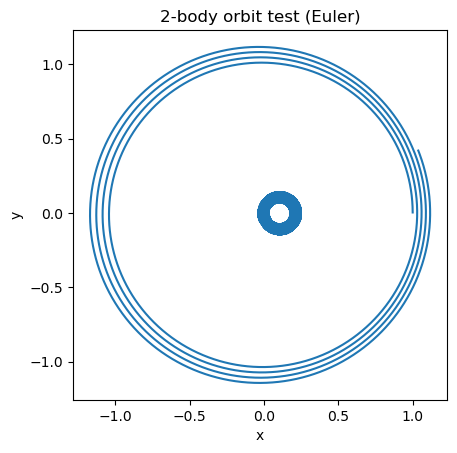

In [8]:
G = 1.0

# masses
m = np.array([10.0, 1.0])   # heavy star + light planet

# positions
x = np.array([[0.0, 0.0, 0.0],   # star at origin
              [1.0, 0.0, 0.0]])  # planet at r = 1

# velocities
v = np.array([[0.0, 0.0, 0.0],   # star initially at rest
              [0.0, np.sqrt(G * m[0] / 1.0), 0.0]])  # circular orbit

v[0] = - (m[1] / m[0]) * v[1]

dt = 0.001
nsteps = 10000
x_hist_e = []

for step in range(nsteps):
    x, v = integrators.step_euler(x, v, m, dt)
    x_hist_e.append(x.copy())

x_hist_e = np.array(x_hist_e)

import matplotlib.pyplot as plt

# planet trajectory
plt.plot(x_hist_e[:,1,0], x_hist_e[:,1,1])

# star position
plt.scatter(x_hist_e[:,0,0], x_hist_e[:,0,1])

plt.gca().set_aspect('equal')
plt.xlabel("x")
plt.ylabel("y")
plt.title("2-body orbit test (Euler)")

plt.show()

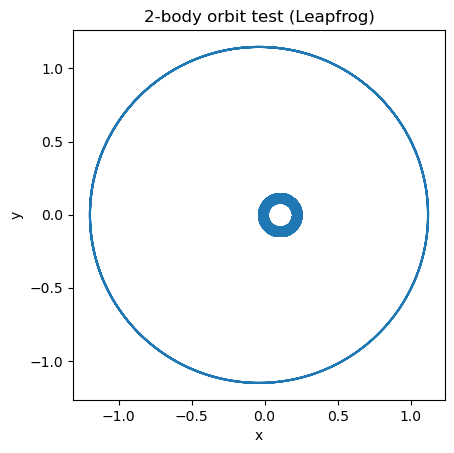

In [9]:
x_hist_l = []

for step in range(nsteps):
    x, v = integrators.step_leapfrog(x, v, m, dt)
    x_hist_l.append(x.copy())

x_hist_l = np.array(x_hist_l)

import matplotlib.pyplot as plt

# planet trajectory
plt.plot(x_hist_l[:,1,0], x_hist_l[:,1,1])

# star position
plt.scatter(x_hist_l[:,0,0], x_hist_l[:,0,1])

plt.gca().set_aspect('equal')
plt.xlabel("x")
plt.ylabel("y")
plt.title("2-body orbit test (Leapfrog)")

plt.show()

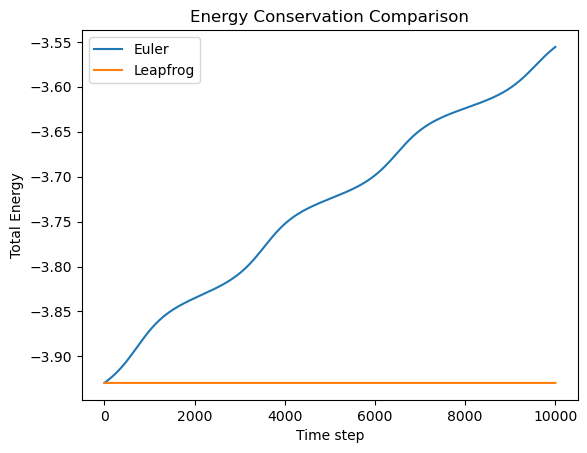

In [10]:
x_e = x.copy()
v_e = v.copy()

energy_e = []

for step in range(nsteps):
    x_e, v_e = integrators.step_euler(x_e, v_e, m, dt)
    energy_e.append(analysis.compute_energy(x_e, v_e, m))

x_l = x.copy()
v_l = v.copy()

energy_l = []

for step in range(nsteps):
    x_l, v_l = integrators.step_leapfrog(x_l, v_l, m, dt)
    energy_l.append(analysis.compute_energy(x_l, v_l, m))

plt.plot(energy_e, label="Euler")
plt.plot(energy_l, label="Leapfrog")

plt.xlabel("Time step")
plt.ylabel("Total Energy")
plt.legend()
plt.title("Energy Conservation Comparison")

plt.show()

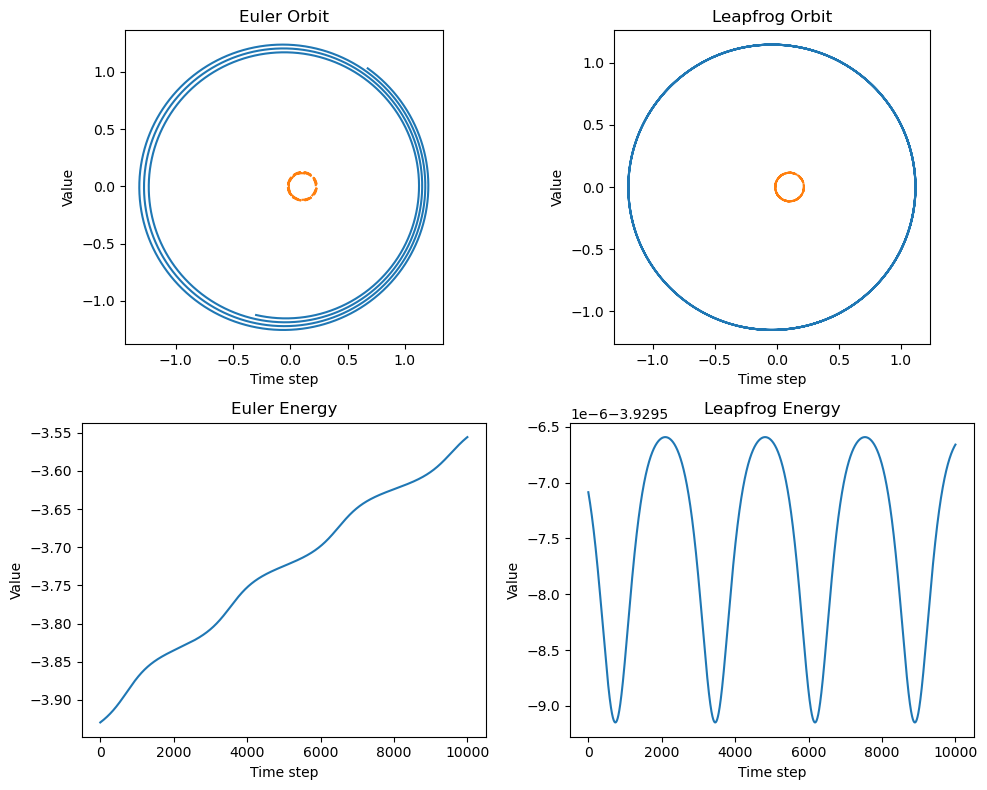

In [11]:
x_e = x.copy()
v_e = v.copy()

traj_e = []
energy_e = []

for step in range(nsteps):
    x_e, v_e = integrators.step_euler(x_e, v_e, m, dt)
    traj_e.append(x_e.copy())
    energy_e.append(analysis.compute_energy(x_e, v_e, m))

traj_e = np.array(traj_e)

x_l = x.copy()
v_l = v.copy()

traj_l = []
energy_l = []

for step in range(nsteps):
    x_l, v_l = integrators.step_leapfrog(x_l, v_l, m, dt)
    traj_l.append(x_l.copy())
    energy_l.append(analysis.compute_energy(x_l, v_l, m))

traj_l = np.array(traj_l)

import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

# --- Euler orbit ---
axes[0,0].plot(traj_e[:,1,0], traj_e[:,1,1])
axes[0,0].set_title("Euler Orbit")
axes[0,0].set_aspect('equal')

# --- Leapfrog orbit ---
axes[0,1].plot(traj_l[:,1,0], traj_l[:,1,1])
axes[0,1].set_title("Leapfrog Orbit")
axes[0,1].set_aspect('equal')

# --- Euler energy ---
axes[1,0].plot(energy_e)
axes[1,0].set_title("Euler Energy")

# --- Leapfrog energy ---
axes[1,1].plot(energy_l)
axes[1,1].set_title("Leapfrog Energy")

for ax in axes.flat:
    ax.set_xlabel("Time step")
    ax.set_ylabel("Value")

axes[0,0].plot(traj_e[:,0,0], traj_e[:,0,1], linestyle="--")
axes[0,1].plot(traj_l[:,0,0], traj_l[:,0,1], linestyle="--")

plt.tight_layout()
plt.savefig("../plots/orbit_energy_comparison.png", dpi=200)
plt.show()

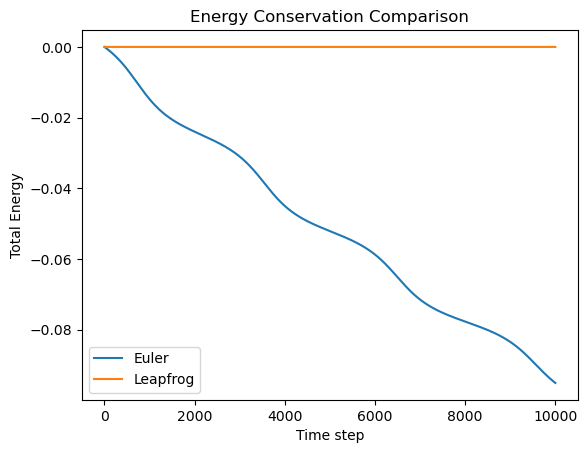

In [12]:
# --- Relative energy error ---
energy_e_rel = (energy_e - energy_e[0]) / energy_e[0]
energy_l_rel = (energy_l - energy_l[0]) / energy_l[0]

plt.plot(energy_e_rel, label="Euler")
plt.plot(energy_l_rel, label="Leapfrog")

plt.xlabel("Time step")
plt.ylabel("Total Energy")
plt.legend()
plt.title("Energy Conservation Comparison")

plt.show()